In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("loan_approval_1000.csv")
df


,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,Salaried,0
1,49,141178.0,328226,487,Salaried,0
2,35,56368.0,312805,356,Self-Employed,0
3,28,26783.0,218484,319,Salaried,0
4,41,131530.0,315064,572,Self-Employed,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,Unemployed,0
996,22,134994.0,314167,544,Unemployed,0
997,27,109899.0,169654,749,Salaried,1
998,38,40049.0,240868,546,Unemployed,0


In [ ]:
df.isna().sum()

,0
Age,0
Income,50
Loan_Amount,0
Credit_Score,0
Employment_Type,50
Loan_Approved,0


In [ ]:
len(df)

1000

In [ ]:
df["Employment_Type"].value_counts()

,count
Employment_Type,
0,471
1,287
2,192
3,50


In [ ]:
mu=df["Income"].mean()

mod=df["Employment_Type"].mode()[0]

In [ ]:
df["Employment_Type"].mode()

,Employment_Type
0,0


In [ ]:
df["Income"]=df["Income"].fillna(mu)
df["Employment_Type"]=df["Employment_Type"].fillna(mod)

In [ ]:
df.isna().sum()

,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Employment_Type,0
Loan_Approved,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Employment_Type']=le.fit_transform(df['Employment_Type'])



In [ ]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,0,0
1,49,141178.0,328226,487,0,0
2,35,56368.0,312805,356,1,0
3,28,26783.0,218484,319,0,0
4,41,131530.0,315064,572,1,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,2,0
996,22,134994.0,314167,544,2,0
997,27,109899.0,169654,749,0,1
998,38,40049.0,240868,546,2,0


In [ ]:
le.classes_

array([0, 1, 2, 3])

In [ ]:
from sklearn.model_selection import train_test_split

x= df.drop("Loan_Approved", axis=1)

y=df["Loan_Approved"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

x_train.shape,x_test.shape



((800, 5), (200, 5))

In [ ]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred=lr.predict(x_test)


In [ ]:
y_pred

array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1])

In [ ]:
y_test

,Loan_Approved
521,1
737,0
740,0
660,1
411,1
...,...
408,1
332,1
208,0
613,0


In [ ]:
from sklearn.metrics import classification_report, accuracy_score



print("accuray Score",accuracy_score(y_test,y_pred))
print("Classification Report\n",classification_report(y_test,y_pred))



accuray Score 0.785
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.87      0.85       135
           1       0.70      0.60      0.64        65

    accuracy                           0.79       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.78      0.79      0.78       200



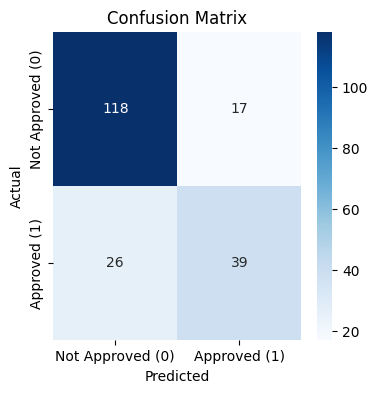

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved (0)", "Approved (1)"],
    yticklabels=["Not Approved (0)", "Approved (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
